# EDA: Project Gutenberg Database

Abraham Tedla (wqp7qy@virginia.edu)  
DS 5001  
April 2026

Explore the `gutenberg.db` SQLite catalog to understand the data and select a corpus.

# Set Up

In [83]:
db_path = 'gutenberg.db'

# Placeholder value used in the DB for missing data
NONE_VALS = ['NONE GIVEN', 'NONE', '']

# Genre keywords we care about for corpus selection
genre_keywords = {
    'Gothic Fiction': 'GOTHIC',
    'Science Fiction': 'SCIENCE FICTION',
    'Horror': 'HORROR',
    'Mystery/Detective': 'DETECTIVE|MYSTERY',
    'Adventure': 'ADVENTURE',
    "Children's Literature": 'CHILDREN',
}

## Imports

In [84]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns

In [85]:
sns.set()
%matplotlib inline

# Load the Catalog

In [86]:
conn = sqlite3.connect(db_path)
catalog = pd.read_sql_query('SELECT * FROM catalog', conn)
conn.close()

In [87]:
catalog.shape

(61575, 10)

In [88]:
catalog.head()

,gid,agents,bookshelves,creators,formats,languages,rights,subjects,title,types
0,0,NONE GIVEN,NONE GIVEN,NONE GIVEN,NONE GIVEN,EN,NONE,NONE GIVEN,NONE GIVEN,TEXT
1,1,NONE GIVEN,AMERICAN REVOLUTIONARY WAR\nPOLITICS\nUNITED S...,"JEFFERSON, THOMAS",APPLICATION/EPUB+ZIP\nAPPLICATION/EPUB+ZIP\nAP...,EN,PUBLIC DOMAIN IN THE USA.,UNITED STATES. DECLARATION OF INDEPENDENCE\nJK...,THE DECLARATION OF INDEPENDENCE OF THE UNITED ...,TEXT
2,2,NONE GIVEN,AMERICAN REVOLUTIONARY WAR\nUNITED STATES LAW\...,UNITED STATES,APPLICATION/EPUB+ZIP\nAPPLICATION/EPUB+ZIP\nAP...,EN,PUBLIC DOMAIN IN THE USA.,KF\nCIVIL RIGHTS -- UNITED STATES -- SOURCES\n...,THE UNITED STATES BILL OF RIGHTS THE TEN ORIGI...,TEXT
3,3,NONE GIVEN,NONE GIVEN,"KENNEDY, JOHN F. (JOHN FITZGERALD)",APPLICATION/EPUB+ZIP\nAPPLICATION/EPUB+ZIP\nAP...,EN,PUBLIC DOMAIN IN THE USA.,UNITED STATES -- FOREIGN RELATIONS -- 1961-196...,JOHN F. KENNEDY'S INAUGURAL ADDRESS,TEXT
4,4,NONE GIVEN,US CIVIL WAR,"LINCOLN, ABRAHAM",APPLICATION/EPUB+ZIP\nAPPLICATION/EPUB+ZIP\nAP...,EN,PUBLIC DOMAIN IN THE USA.,"SOLDIERS' NATIONAL CEMETERY (GETTYSBURG, PA.)\...",LINCOLN'S GETTYSBURG ADDRESS GIVEN NOVEMBER 19...,TEXT


In [89]:
catalog.dtypes

gid             int64
agents         object
bookshelves    object
creators       object
formats        object
languages      object
rights         object
subjects       object
title          object
types          object
dtype: object

In [90]:
catalog.sample(5)

,gid,agents,bookshelves,creators,formats,languages,rights,subjects,title,types
20387,20387,NONE GIVEN,HORROR,"JAMES, M. R. (MONTAGUE RHODES)",APPLICATION/EPUB+ZIP\nAPPLICATION/EPUB+ZIP\nAP...,EN,PUBLIC DOMAIN IN THE USA.,"SHORT STORIES, ENGLISH\nPR\nHORROR TALES, ENGL...",A THIN GHOST AND OTHERS,TEXT
15063,15063,"CRAIG, FRANK","BESTSELLERS, AMERICAN, 1895-1923","BENNETT, ARNOLD",APPLICATION/EPUB+ZIP\nAPPLICATION/EPUB+ZIP\nAP...,EN,PUBLIC DOMAIN IN THE USA.,UNITED STATES -- SOCIAL LIFE AND CUSTOMS -- 18...,YOUR UNITED STATES: IMPRESSIONS OF A FIRST VISIT,TEXT
27003,27003,NONE GIVEN,NOTES AND QUERIES,VARIOUS,APPLICATION/EPUB+ZIP\nAPPLICATION/EPUB+ZIP\nAP...,EN,PUBLIC DOMAIN IN THE USA.,QUESTIONS AND ANSWERS -- PERIODICALS\nAG,"NOTES AND QUERIES, NUMBER 203, SEPTEMBER 17, 1...",TEXT
34181,34181,NONE GIVEN,NONE GIVEN,"ROS, AMANDA MCKITTRICK",APPLICATION/EPUB+ZIP\nAPPLICATION/EPUB+ZIP\nAP...,EN,PUBLIC DOMAIN IN THE USA.,FICTION\nPR,IRENE IDDESLEIGH,TEXT
56656,56656,NONE GIVEN,NONE GIVEN,"HASLAM, JOHN",APPLICATION/EPUB+ZIP\nAPPLICATION/EPUB+ZIP\nAP...,EN,PUBLIC DOMAIN IN THE USA.,MENTAL ILLNESS -- JURISPRUDENCE\nINSANITY (LAW...,MEDICAL JURISPRUDENCE AS IT RELATES TO INSANIT...,TEXT


# Data Quality

The database uses `'NONE GIVEN'` and `'NONE'` as placeholders for missing data. Let's see how prevalent they are.

In [91]:
placeholder_counts = {}
for col in catalog.columns:
    if catalog[col].dtype == 'object':
        mask = catalog[col].isin(NONE_VALS)
        placeholder_counts[col] = mask.sum()

quality = pd.DataFrame({
    'placeholder_or_empty': placeholder_counts,
    'total': len(catalog)
})
quality['pct_missing'] = (quality['placeholder_or_empty'] / quality['total'] * 100).round(1)
quality.sort_values('pct_missing', ascending=False)

,placeholder_or_empty,total,pct_missing
agents,55474,61575,90.1
bookshelves,44547,61575,72.3
creators,2516,61575,4.1
subjects,251,61575,0.4
formats,127,61575,0.2
rights,126,61575,0.2
title,131,61575,0.2
languages,1,61575,0.0
types,0,61575,0.0


# Content Types

In [92]:
catalog['types'].value_counts()

types
TEXT           60326
SOUND           1114
DATASET           88
IMAGE             33
MOVINGIMAGE        8
STILLIMAGE         3
COLLECTION         3
Name: count, dtype: int64

<Axes: ylabel='types'>

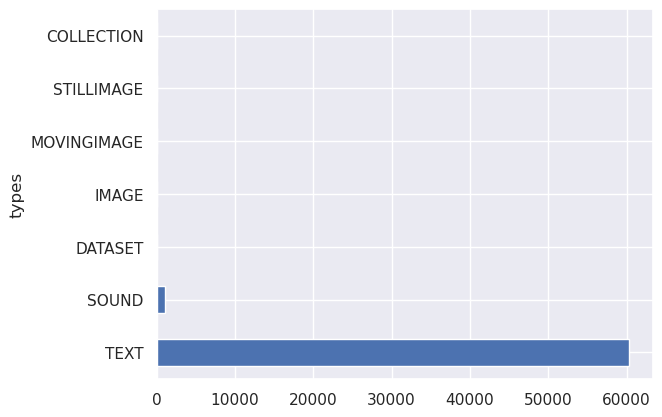

In [93]:
catalog['types'].value_counts().plot.barh()

# Language Distribution

Multi-value fields are newline-delimited. We take the first language listed.

In [94]:
catalog['primary_language'] = catalog['languages'].str.split('\n').str[0]

In [95]:
catalog['primary_language'].value_counts().head(15)

primary_language
EN    50130
FR     3050
FI     2135
DE     1812
NL      812
IT      808
ES      644
PT      552
ZH      437
EL      219
SV      201
HU      191
EO      114
LA      110
DA       70
Name: count, dtype: int64

<Axes: ylabel='primary_language'>

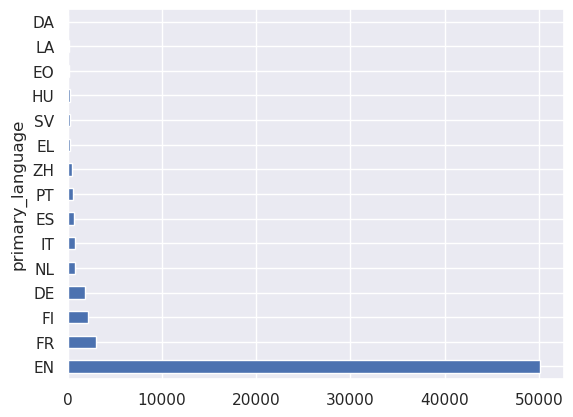

In [96]:
catalog['primary_language'].value_counts().head(15).plot.barh()

In [97]:
en_pct = (catalog['primary_language'] == 'EN').mean() * 100
print(f'English works: {en_pct:.1f}% of catalog')

English works: 81.4% of catalog


# Bookshelves (Genre) Analysis

Bookshelves are newline-separated. Explode them to analyze genre distribution.

In [98]:
shelves = catalog[~catalog['bookshelves'].isin(NONE_VALS)].copy()
shelves['shelf_list'] = shelves['bookshelves'].str.split('\n')
shelves_exploded = shelves.explode('shelf_list')
shelves_exploded['shelf_list'] = shelves_exploded['shelf_list'].str.strip()

In [99]:
shelf_counts = shelves_exploded['shelf_list'].value_counts()
print(f'Unique bookshelves: {len(shelf_counts)}')
print(f'Works with bookshelf labels: {len(shelves):,} / {len(catalog):,}')

Unique bookshelves: 338
Works with bookshelf labels: 17,028 / 61,575


In [100]:
shelf_counts.head(30)

shelf_list
SCIENCE FICTION                                            1341
FR LITTÉRATURE                                             1068
CHILDREN'S BOOK SERIES                                      509
PUNCH                                                       493
BESTSELLERS, AMERICAN, 1895-1923                            426
HISTORICAL FICTION                                          383
DE PROSA                                                    382
WORLD WAR I                                                 382
CHILDREN'S FICTION                                          339
CHILDREN'S LITERATURE                                       317
FR BIOGRAPHIE, MÉMOIRES, JOURNAL INTIME, CORRESPONDANCE     313
US CIVIL WAR                                                311
DE SACHBUCH                                                 250
ANIMAL                                                      242
TECHNOLOGY                                                  230
L'ILLUSTRATION               

<Axes: ylabel='shelf_list'>

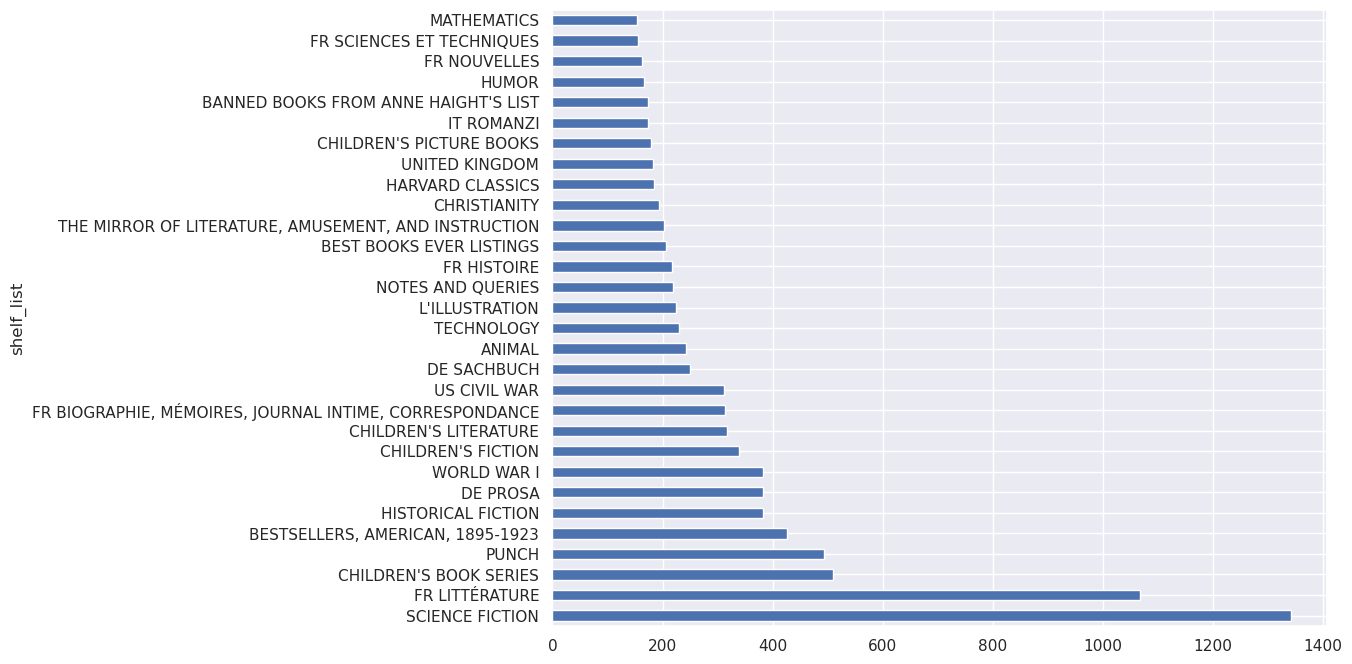

In [101]:
shelf_counts.head(30).plot.barh(figsize=(10, 8))

# Focus Genres

Count works matching our target genre keywords.

In [102]:
genre_summary = {}
for label, kw in genre_keywords.items():
    mask = catalog['bookshelves'].str.contains(kw, case=False, na=False)
    genre_summary[label] = mask.sum()

genre_df = pd.Series(genre_summary).sort_values(ascending=False)
genre_df

Children's Literature    1649
Science Fiction          1395
Mystery/Detective         117
Adventure                  82
Horror                     49
Gothic Fiction             30
dtype: int64

<Axes: >

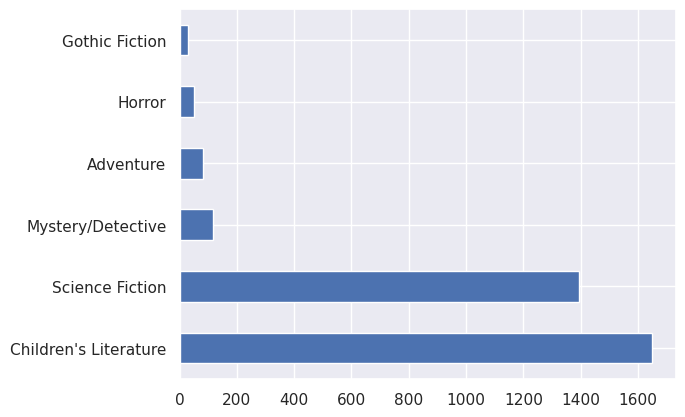

In [103]:
genre_df.plot.barh()

# Gothic Fiction Titles

In [104]:
gothic = catalog[
    catalog['bookshelves'].str.contains('GOTHIC', case=False, na=False)
    & (catalog['primary_language'] == 'EN')
    & (catalog['types'] == 'TEXT')
].copy()
print(f'English Gothic Fiction texts: {len(gothic)}')

English Gothic Fiction texts: 25


In [105]:
gothic[['gid', 'title', 'creators', 'bookshelves']].sort_values('title')

,gid,title,creators,bookshelves
11323,11323,"CALEB WILLIAMS; OR, THINGS AS THEY ARE","GODWIN, WILLIAM",GOTHIC FICTION
10007,10007,CARMILLA,"LE FANU, JOSEPH SHERIDAN",HORROR\nGOTHIC FICTION
2040,2040,CONFESSIONS OF AN ENGLISH OPIUM-EATER,"DE QUINCEY, THOMAS",GOTHIC FICTION
345,345,DRACULA,"STOKER, BRAM",MYSTERY FICTION\nHORROR\nMOVIE BOOKS\nGOTHIC F...
84,84,"FRANKENSTEIN; OR, THE MODERN PROMETHEUS","SHELLEY, MARY WOLLSTONECRAFT",GOTHIC FICTION\nPRECURSORS OF SCIENCE FICTION\...
512,512,"MOSSES FROM AN OLD MANSE, AND OTHER STORIES","HAWTHORNE, NATHANIEL",GOTHIC FICTION
9909,9909,NIGHTMARE ABBEY,"PEACOCK, THOMAS LOVE",GOTHIC FICTION
121,121,NORTHANGER ABBEY,"AUSTEN, JANE",GOTHIC FICTION
696,696,THE CASTLE OF OTRANTO,"WALPOLE, HORACE",GOTHIC FICTION
2060,2060,THE HISTORY OF CALIPH VATHEK,"BECKFORD, WILLIAM",GOTHIC FICTION\nFANTASY


# Science Fiction Titles

In [106]:
scifi = catalog[
    catalog['bookshelves'].str.contains('SCIENCE FICTION', case=False, na=False)
    & (catalog['primary_language'] == 'EN')
    & (catalog['types'] == 'TEXT')
].copy()
print(f'English Science Fiction texts: {len(scifi)}')

English Science Fiction texts: 1326


In [107]:
scifi[['gid', 'title', 'creators', 'bookshelves']].head(30)

,gid,title,creators,bookshelves
35,35,THE TIME MACHINE,"WELLS, H. G. (HERBERT GEORGE)",SCIENCE FICTION\nMOVIE BOOKS
36,36,THE WAR OF THE WORLDS,"WELLS, H. G. (HERBERT GEORGE)",MOVIE BOOKS\nSCIENCE FICTION
42,42,THE STRANGE CASE OF DR. JEKYLL AND MR. HYDE,"STEVENSON, ROBERT LOUIS",HORROR\nGOTHIC FICTION\nMOVIE BOOKS\nPRECURSOR...
43,43,THE STRANGE CASE OF DR. JEKYLL AND MR. HYDE,"STEVENSON, ROBERT LOUIS",HORROR\nPRECURSORS OF SCIENCE FICTION\nMOVIE B...
62,62,A PRINCESS OF MARS,"BURROUGHS, EDGAR RICE",SCIENCE FICTION\nBEST BOOKS EVER LISTINGS
64,64,THE GODS OF MARS,"BURROUGHS, EDGAR RICE",SCIENCE FICTION
68,68,WARLORD OF MARS,"BURROUGHS, EDGAR RICE",SCIENCE FICTION
72,72,"THUVIA, MAID OF MARS","BURROUGHS, EDGAR RICE",SCIENCE FICTION
83,83,"FROM THE EARTH TO THE MOON; AND, ROUND THE MOON","VERNE, JULES",SCIENCE FICTION\nMOVIE BOOKS
84,84,"FRANKENSTEIN; OR, THE MODERN PROMETHEUS","SHELLEY, MARY WOLLSTONECRAFT",GOTHIC FICTION\nPRECURSORS OF SCIENCE FICTION\...


# Horror Titles

In [108]:
horror = catalog[
    catalog['bookshelves'].str.contains('HORROR', case=False, na=False)
    & (catalog['primary_language'] == 'EN')
    & (catalog['types'] == 'TEXT')
].copy()
print(f'English Horror texts: {len(horror)}')

English Horror texts: 43


In [109]:
horror[['gid', 'title', 'creators', 'bookshelves']].sort_values('title')

,gid,title,creators,bookshelves
20387,20387,A THIN GHOST AND OTHERS,"JAMES, M. R. (MONTAGUE RHODES)",HORROR
375,375,AN OCCURRENCE AT OWL CREEK BRIDGE,"BIERCE, AMBROSE",HORROR\nUS CIVIL WAR
18233,18233,"ANIMAL GHOSTS; OR, ANIMAL HAUNTINGS AND THE HE...","O'DONNELL, ELLIOTT",HORROR
10007,10007,CARMILLA,"LE FANU, JOSEPH SHERIDAN",HORROR\nGOTHIC FICTION
345,345,DRACULA,"STOKER, BRAM",MYSTERY FICTION\nHORROR\nMOVIE BOOKS\nGOTHIC F...
10150,10150,DRACULA'S GUEST,"STOKER, BRAM",HORROR
16726,16726,FOUR WEIRD TALES,"BLACKWOOD, ALGERNON",HORROR
8486,8486,GHOST STORIES OF AN ANTIQUARY,"JAMES, M. R. (MONTAGUE RHODES)",HORROR
9629,9629,GHOST STORIES OF AN ANTIQUARY PART 2: MORE GHO...,"JAMES, M. R. (MONTAGUE RHODES)",HORROR
5200,5200,METAMORPHOSIS,"KAFKA, FRANZ",HORROR


# Top Authors in Focus Genres

In [110]:
focus = catalog[
    catalog['bookshelves'].str.contains('GOTHIC|SCIENCE FICTION|HORROR', case=False, na=False)
    & (catalog['primary_language'] == 'EN')
    & (catalog['types'] == 'TEXT')
].copy()
focus['primary_creator'] = focus['creators'].str.split('\n').str[0]

In [111]:
focus['primary_creator'].value_counts().head(20)

primary_creator
GARRETT, RANDALL                      45
LEINSTER, MURRAY                      36
PIPER, H. BEAM                        31
VARIOUS                               27
LEIBER, FRITZ                         19
SHECKLEY, ROBERT                      19
NOURSE, ALAN EDWARD                   18
REYNOLDS, MACK                        17
SMITH, EVELYN E.                      17
MARLOWE, STEPHEN                      16
FYFE, H. B. (HORACE BOWNE)            15
BURROUGHS, EDGAR RICE                 14
WELLS, H. G. (HERBERT GEORGE)         13
HARMON, JIM                           13
DICK, PHILIP K.                       13
BONE, JESSE F. (JESSE FRANKLIN)       12
AYCOCK, ROGER D.                      12
SMITH, E. E. (EDWARD ELMER)           12
DEL REY, LESTER                       12
MARKS, WINSTON K. (WINSTON KINNEY)    12
Name: count, dtype: int64

<Axes: ylabel='primary_creator'>

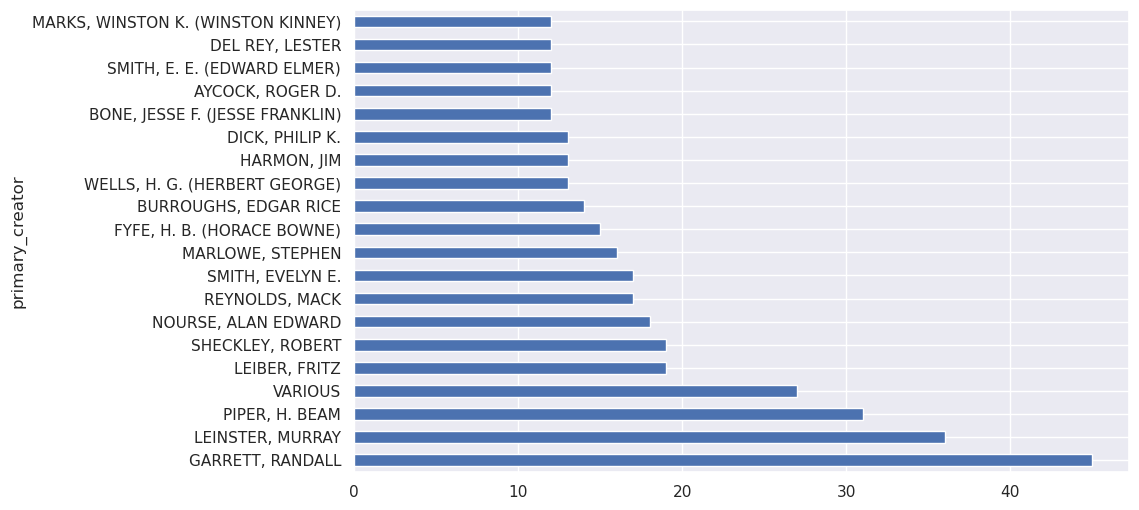

In [112]:
focus['primary_creator'].value_counts().head(20).plot.barh(figsize=(10, 6))

# Plaintext Availability

We need `TEXT/PLAIN` format to download and parse.

In [113]:
focus['has_plaintext'] = focus['formats'].str.contains('TEXT/PLAIN', case=False, na=False)
print(f"Focus genre works with plaintext: {focus['has_plaintext'].sum()} / {len(focus)}")
print(f"Percentage: {focus['has_plaintext'].mean()*100:.1f}%")

Focus genre works with plaintext: 1380 / 1381
Percentage: 99.9%


# Rights / License

In [114]:
catalog['rights'].value_counts()

rights
PUBLIC DOMAIN IN THE USA.                                               60493
COPYRIGHTED. READ THE COPYRIGHT NOTICE INSIDE THIS BOOK FOR DETAILS.      956
NONE                                                                      126
Name: count, dtype: int64

# Subjects in Focus Genres

In [115]:
subj_df = focus[~focus['subjects'].isin(NONE_VALS)].copy()
subj_df['subj_list'] = subj_df['subjects'].str.split('\n')
subj_exploded = subj_df.explode('subj_list')
subj_exploded['subj_list'] = subj_exploded['subj_list'].str.strip()

In [116]:
subj_exploded['subj_list'].value_counts().head(25)

subj_list
PS                                          1232
SCIENCE FICTION                             1158
SHORT STORIES                                677
HUMAN-ALIEN ENCOUNTERS -- FICTION             98
PR                                            74
EXTRATERRESTRIAL BEINGS -- FICTION            64
TIME TRAVEL -- FICTION                        52
MARS (PLANET) -- FICTION                      46
SCIENCE FICTION, AMERICAN                     40
PSYCHOLOGICAL FICTION                         37
FANTASY FICTION                               36
HORROR TALES                                  36
PARAPSYCHOLOGY -- FICTION                     36
PN                                            31
SPACE COLONIES -- FICTION                     29
LIFE ON OTHER PLANETS -- FICTION              26
SPACE SHIPS -- FICTION                        26
WAR STORIES                                   25
SCIENCE FICTION -- PERIODICALS                24
ROBOTS -- FICTION                             23
SPACE FLIG

<Axes: ylabel='subj_list'>

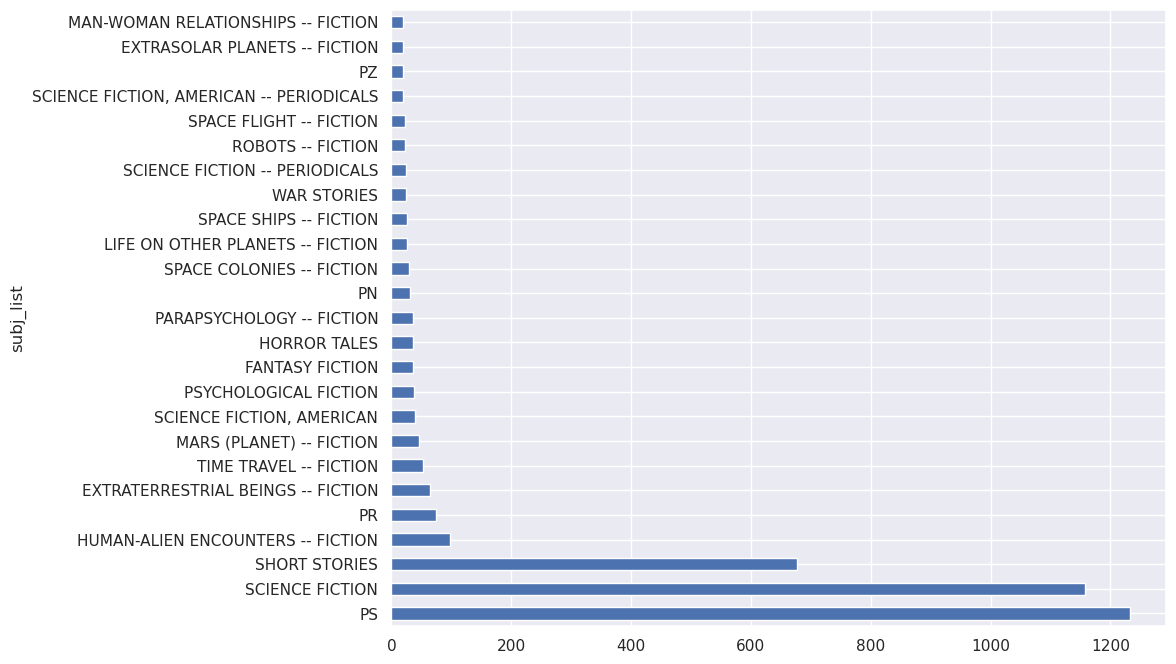

In [117]:
subj_exploded['subj_list'].value_counts().head(25).plot.barh(figsize=(10, 8))

# Candidate Corpus

Filter to English TEXT works in Gothic / Sci-Fi / Horror with plaintext available. Assign genre labels.

In [118]:
candidates = catalog[
    catalog['bookshelves'].str.contains('GOTHIC|SCIENCE FICTION|HORROR', case=False, na=False)
    & (catalog['primary_language'] == 'EN')
    & (catalog['types'] == 'TEXT')
    & catalog['formats'].str.contains('TEXT/PLAIN', case=False, na=False)
].copy()
candidates['primary_creator'] = candidates['creators'].str.split('\n').str[0]

In [119]:
def assign_genre(row):
    shelves = row['bookshelves'].upper()
    genres = []
    if 'GOTHIC' in shelves:
        genres.append('Gothic')
    if 'SCIENCE FICTION' in shelves:
        genres.append('SciFi')
    if 'HORROR' in shelves:
        genres.append('Horror')
    return ', '.join(genres) if genres else 'Other'

candidates['genre'] = candidates.apply(assign_genre, axis=1)

In [120]:
print(f'Total candidates: {len(candidates)}')
candidates['genre'].value_counts()

Total candidates: 1380


genre
SciFi                    1319
Horror                     32
Gothic                     17
Gothic, Horror              6
SciFi, Horror               4
Gothic, SciFi, Horror       1
Gothic, SciFi               1
Name: count, dtype: int64

In [121]:
candidates[['gid', 'title', 'primary_creator', 'genre']].sort_values('genre')

,gid,title,primary_creator,genre
768,768,WUTHERING HEIGHTS,"BRONTË, EMILY",Gothic
601,601,THE MONK: A ROMANCE,"LEWIS, M. G. (MATTHEW GREGORY)",Gothic
2276,2276,THE PRIVATE MEMOIRS AND CONFESSIONS OF A JUSTI...,"HOGG, JAMES",Gothic
512,512,"MOSSES FROM AN OLD MANSE, AND OTHER STORIES","HAWTHORNE, NATHANIEL",Gothic
9909,9909,NIGHTMARE ABBEY,"PEACOCK, THOMAS LOVE",Gothic
...,...,...,...,...
25627,25627,THE HUNTED HEROES,"SILVERBERG, ROBERT",SciFi
10002,10002,THE HOUSE ON THE BORDERLAND,"HODGSON, WILLIAM HOPE","SciFi, Horror"
10662,10662,THE NIGHT LAND,"HODGSON, WILLIAM HOPE","SciFi, Horror"
43,43,THE STRANGE CASE OF DR. JEKYLL AND MR. HYDE,"STEVENSON, ROBERT LOUIS","SciFi, Horror"


# Summary & Next Steps

- Catalog has ~61.5K entries, ~50K English, ~60K TEXT type.
- Multi-value fields (bookshelves, subjects, formats, creators) are newline-delimited.
- Gothic Fiction (30), Science Fiction (1,400), Horror (49) provide a rich corpus.
- Nearly all works have plaintext format available.

**Next:** Select 10–15 novels from these candidates and proceed to Step 1 (Corpus Acquisition & F0/F1).